In [538]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [539]:
X = 6 * np.random.rand(100,1) - 3
y = .5*X**2 + 1.5*X + np.random.randn(100,1)

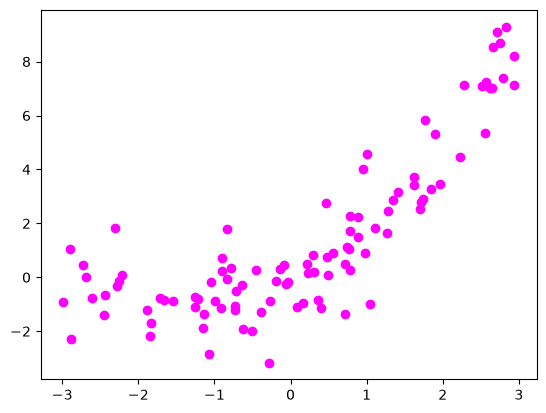

In [540]:
plt.scatter(X,y,color='magenta')

In [541]:
# Train test split
from sklearn.model_selection import train_test_split

In [542]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [543]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [544]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [545]:
# Implement Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [546]:
reg = LinearRegression()

In [547]:
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[2.33]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.46]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[8.94]


In [548]:
# R square
from sklearn.metrics import r2_score
score = r2_score(y_test,reg.predict(X_test))

print(f"R Square: {score}")
print(f"Adjusted R Square: {1-(1-score)*(len(y_test)-1)/(len(y_test)-X_train.shape[1]-1)}")

R Square: 0.75357107378797
Adjusted R Square: 0.7398805778873017


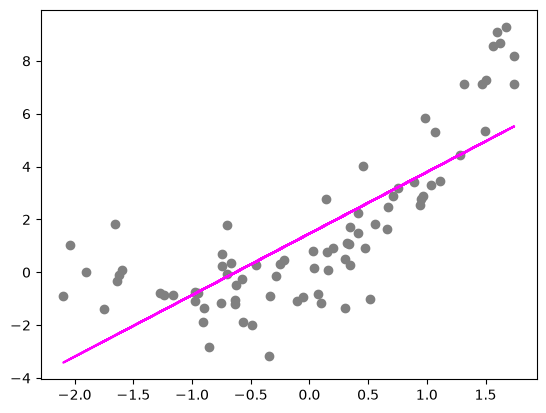

In [549]:
# Visualizing model
plt.plot(X_train,reg.predict(X_train),color='magenta')
plt.scatter(X_train,y_train,color='gray')

In [550]:
# Implement Polynomial tranformation
from sklearn.preprocessing import PolynomialFeatures

In [551]:
poly = PolynomialFeatures(degree=2,include_bias=True)

In [552]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [553]:
reg.fit(X_train_poly,y_train)
y_pred = reg.predict(X_test_poly)

In [554]:
score_poly = r2_score(y_test,y_pred)
score_poly

0.8639004162847581

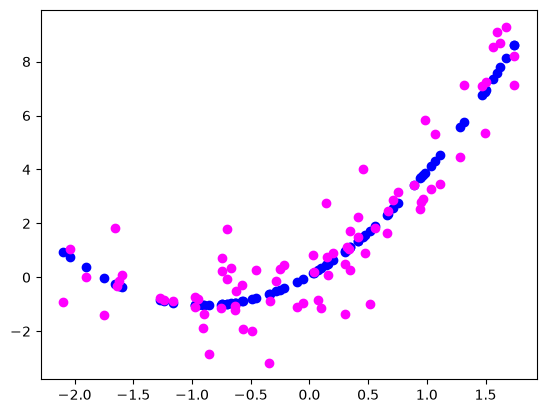

In [555]:
plt.scatter(X_train,reg.predict(X_train_poly),color='blue')
plt.scatter(X_train,y_train,color='magenta')

In [556]:
poly_3 = PolynomialFeatures(degree=3,include_bias=True)
X_train_3 = poly_3.fit_transform(X_train)
X_test_3 = poly_3.transform(X_test)

In [557]:
reg.fit(X_train_3,y_train)
y_pred3 = reg.predict(X_test_3)

In [558]:
score_3 = r2_score(y_test,y_pred3)
score_3

0.8638241888405279

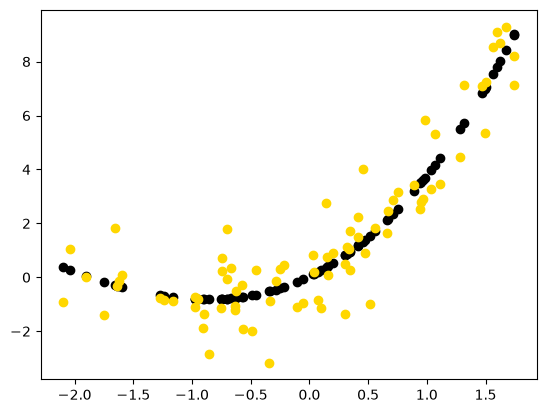

In [559]:
plt.scatter(X_train,reg.predict(X_train_3),color='black')
plt.scatter(X_train,y_train,color='gold')

In [560]:
# Prediction of new Data
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly_3.transform(X_new)

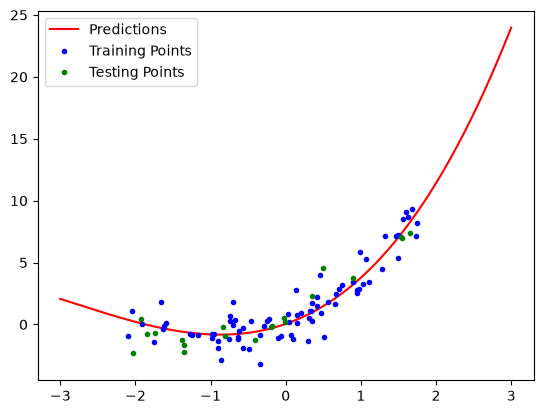

In [561]:
y_new = reg.predict(X_new_poly)
plt.plot(X_new, y_new, "r-",label='Predictions')
plt.plot(X_train, y_train, "b.",label='Training Points')
plt.plot(X_test, y_test, "g.",label='Testing Points')
plt.legend()
plt.show()